In [1]:
#IBM Telco Customer Churn dataset


In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score, #it measures how well can the model distinguish between two class
                             confusion_matrix,
                             classification_report)


In [6]:
#Load Dataset
dataset = load_dataset("scikit-learn/churn-prediction")

README.md:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

dataset.csv:   0%|          | 0.00/970k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7043 [00:00<?, ? examples/s]

In [7]:

df = dataset ["train"].to_pandas()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
#Explore Data
print ( " number of rows or samples:" , df.shape[0])
print(" number of columns or features:" , df.shape[1])

print( "\n information:")
df.info()

print ("\n description:")
print(df.describe())

print("\n missing data:" )
print(df.isnull().sum().sum())

print(" \n column names:")
print (df.columns)


 number of rows or samples: 7043
 number of columns or features: 21

 information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contra

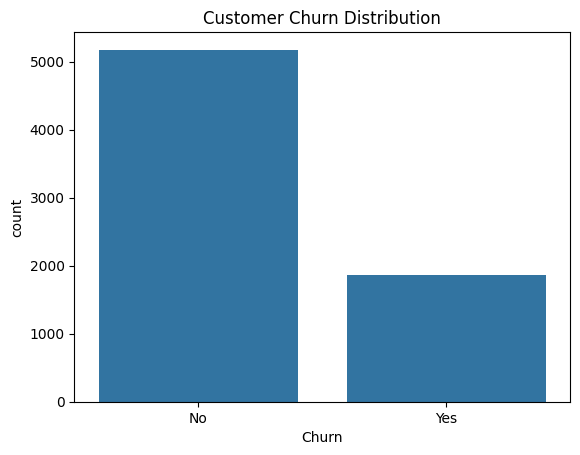

In [11]:
#check target distribution
sns.countplot (x = "Churn" ,data=df)
plt.title ("Customer Churn Distribution")
plt.show()

In [14]:
# Data cleaning, for example, columns with customers' ID need to be removed.
if "customerID" in df.columns:
  df.drop("customerID" , axis = 1 , inplace = True)


#covert target variable
df["Churn"] = df["Churn"].map({"Yes":1 , "No": 0})

In [15]:
#Define x and y
x = df.drop("Churn" , axis=1)
y = df["Churn"]

In [16]:
#Split data into training and testing sets
x_train , x_test , y_train , y_test = train_test_split ( x, y , test_size = 0.2 , random_state = 42 , stratify = y)


In [20]:
# preprocessing
#identify numerical and categorical features
numeric_features = x.select_dtypes( include = ["int64" , "float64"]).columns
categorical_features = x.select_dtypes (include = ["object"]).columns

preprocessor = ColumnTransformer(
    transformers = [
        (
         "num", StandardScaler(), numeric_features
        ),
        (
          "cat", OneHotEncoder (handle_unknown = "ignore") ,categorical_features
        ),
    ]
)



In [21]:
#Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter = 1000),
    "Decision Tree": DecisionTreeClassifier(random_state = 42),
    "random Forest": RandomForestClassifier(random_state = 42)
}

In [ ]:
# Train models on trainign data
results = []
for name, model in models.items():

  pipeline = Pipeline = (steps = [("preprocessor": preprocessor ), ("model": model)] )
  pipeline.fir (x_train , y_train)

  #model on testing data
  y_pred = pipeline. predict(x_test)

 y_prob = pipeline.predict_proba (x_test)[:,1]

 results.append({
     "Model": name , "Accuracy": accuracy_score (y_test , y_pred),
     "precision": precision_score (y_test , y_pred),
     "recall" : recall_score (y_test , y_pred),
     "f1 score": f1_score (y_test , y_pred)
     "ROC_AUC" : rac_auc_score (y_test , y_prob)
 })

 print("\n", name)

 print ( classification_report(y_test , y_pred) )

In [ ]:
#compare models
results_df = pd.DataFrame(results)
result_df.sort_values (by =" F1" , ascending = False)